In [ ]:
#1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
#2. load dataset

df = pd.read_csv('/content/healthy_diet_calorie_intake.csv')
df.head()

,Person_ID,Age,Gender,Height_cm,Weight_kg,BMI,Activity_Level,Daily_Calorie_Requirement,Daily_Calorie_Consumed,Protein_Intake_g,Carbohydrate_Intake_g,Fat_Intake_g,Water_Intake_Liters,Diet_Type,Health_Status
0,P0001,50,Male,176.4,74.8,24.0,Very Active,2852,2625,183.0,16.9,202.8,3.3,Keto,Healthy
1,P0002,18,Female,167.6,75.5,26.9,Sedentary,1904,2044,90.1,306.5,50.8,1.9,Vegan,Overweight
2,P0003,68,Female,161.9,87.2,33.3,Lightly Active,2009,2540,222.7,281.3,58.2,2.4,High Protein,Obese
3,P0004,22,Female,169.3,66.9,23.3,Moderately Active,2318,2096,69.5,299.8,68.7,2.9,Balanced,Healthy
4,P0005,30,Male,179.1,75.3,23.5,Sedentary,2144,1937,32.9,285.6,73.7,2.2,Balanced,Healthy


In [ ]:
#3. Create features (inputs)
x = df.drop(["Person_ID", "BMI", "Health_Status"], axis=1)

# Create target (output)
y = df["Health_Status"]
print(x.columns)

Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Activity_Level',
       'Daily_Calorie_Requirement', 'Daily_Calorie_Consumed',
       'Protein_Intake_g', 'Carbohydrate_Intake_g', 'Fat_Intake_g',
       'Water_Intake_Liters', 'Diet_Type'],
      dtype='object')


In [ ]:
#4. Convert categorical feature columns into numeric columns

x = pd.get_dummies(
    x,
    columns=["Gender", "Activity_Level", "Diet_Type"],
    drop_first=True
)
print(x.columns)

Index(['Age', 'Height_cm', 'Weight_kg', 'Daily_Calorie_Requirement',
       'Daily_Calorie_Consumed', 'Protein_Intake_g', 'Carbohydrate_Intake_g',
       'Fat_Intake_g', 'Water_Intake_Liters', 'Gender_Male', 'Gender_Other',
       'Activity_Level_Lightly Active', 'Activity_Level_Moderately Active',
       'Activity_Level_Sedentary', 'Activity_Level_Very Active',
       'Diet_Type_High Protein', 'Diet_Type_Keto', 'Diet_Type_Mediterranean',
       'Diet_Type_Vegan', 'Diet_Type_Vegetarian'],
      dtype='object')


In [ ]:
# IMPORTANT:
# Run this cell only once.
# If you rerun it after y has already been encoded,
# the LabelEncoder will learn numeric labels instead of text labels.
# 5. Create a Label Encoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Convert target labels into numbers
y = le.fit_transform(y)

# Check the mapping
print(le.classes_)
print(y[:10])

[0 1 2 3]
[0 2 1 0 0 0 1 2 1 2]


In [ ]:
#6. Split the dataset into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#7. verify data split
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4800, 20)
(1200, 20)
(4800,)
(1200,)


In [ ]:
#8. Create the Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
#9. Predict the health status for the test data

#y_pred = rf_model.predict(x_test)
#print(y_pred[:10])

#predicted_labels = le.inverse_transform(y_pred)
#print(predicted_labels[:10])
#print(df["Health_Status"].unique())
print(le.classes_)

[0 1 2 3]


In [ ]:
#10. check accuracy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9283333333333333


In [ ]:
#11. classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       458
           1       0.97      0.83      0.89       231
           2       0.88      0.97      0.92       473
           3       1.00      0.82      0.90        38

    accuracy                           0.93      1200
   macro avg       0.95      0.89      0.92      1200
weighted avg       0.93      0.93      0.93      1200



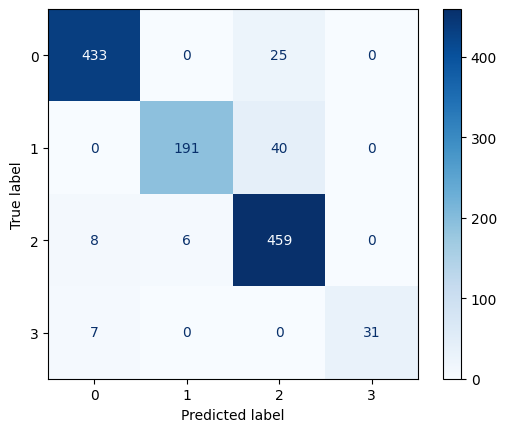

In [ ]:
#12. Confusion matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    rf_model,
    x_test,
    y_test,
    cmap="Blues"
)

plt.show()

In [ ]:
#13. feature importance

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                             Feature  Importance
2                          Weight_kg    0.278507
1                          Height_cm    0.196421
4             Daily_Calorie_Consumed    0.125268
3          Daily_Calorie_Requirement    0.077821
6              Carbohydrate_Intake_g    0.064928
7                       Fat_Intake_g    0.057035
5                   Protein_Intake_g    0.045704
8                Water_Intake_Liters    0.041715
0                                Age    0.038835
9                        Gender_Male    0.018423
13          Activity_Level_Sedentary    0.016644
11     Activity_Level_Lightly Active    0.008831
12  Activity_Level_Moderately Active    0.006897
14        Activity_Level_Very Active    0.004594
19              Diet_Type_Vegetarian    0.003788
17           Diet_Type_Mediterranean    0.003437
10                      Gender_Other    0.003208
15            Diet_Type_High Protein    0.003073
18                   Diet_Type_Vegan    0.002851
16                  

In [105]:
# 14. view output label classes

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

le.fit(df["Health_Status"])

for i, label in enumerate(le.classes_):
    print(f"{i} --> {label}")

0 --> Healthy
1 --> Obese
2 --> Overweight
3 --> Underweight


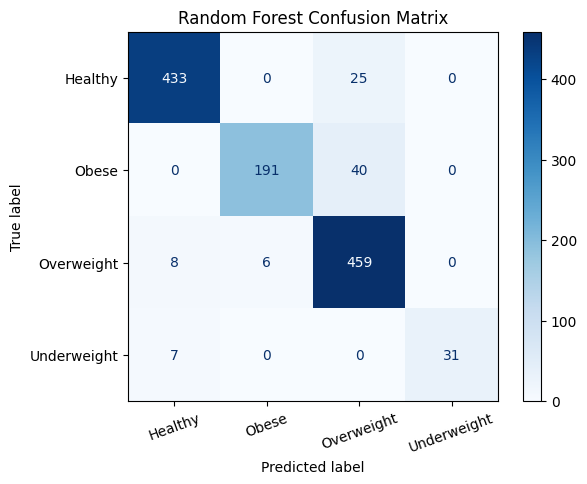

In [106]:
# 15. Confusion Matrix with labels

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix with original class names
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    x_test,
    y_test,
    display_labels=le.classes_,
    cmap="Blues",
    xticks_rotation=20
)

plt.title("Random Forest Confusion Matrix")
plt.show()

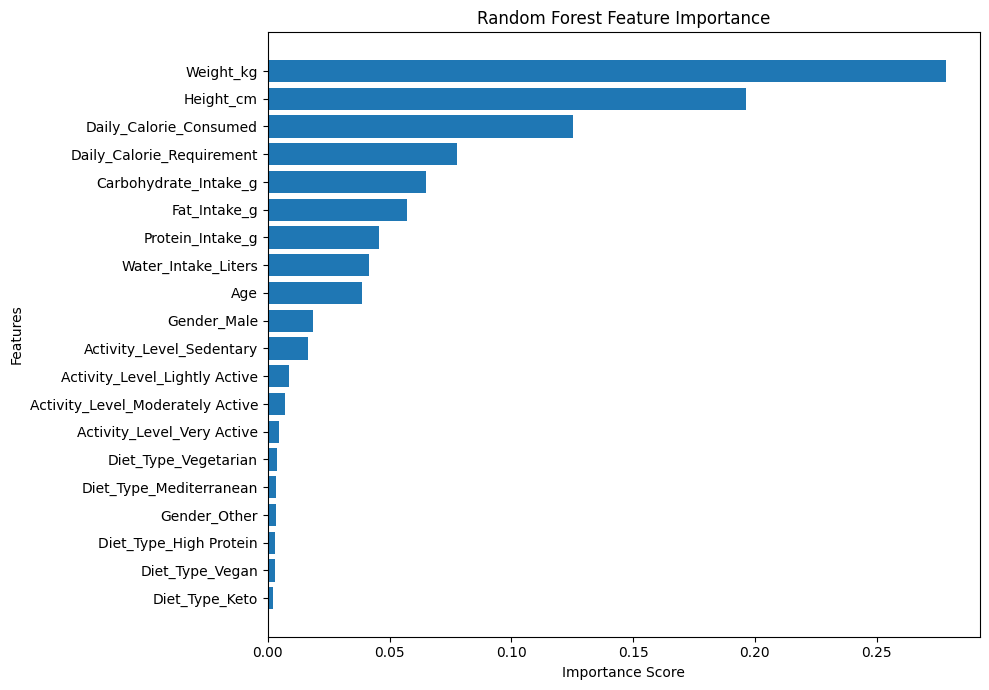

In [107]:
# 16. Create a feature importance chart

importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()

plt.show()